# 3) Extracting and comparing 1D columns from your models

In this notebook, we want to take a look at how to extract information from your geophysical models at a certain point along the profile.

For this, we make use of simple interpolation and visualization functions, either integrated in pyGIMLi or accessible via Matplotlib or NumPy. 

In [1]:
import matplotlib.pyplot as plt
import numpy as np
import pygimli as pg
import pygimli.meshtools as mt
from matplotlib.colors import Normalize, LogNorm

We start by defining a small function to generate interpolated values at a certain x-position along our measured transects.

For this, we require a x- and y-space with a pre-defined number of points as well as our model and the corresponding mesh:

In [2]:
def generate_virtual_borehole(mesh, model, x_coord, n=500):
    ''' Generate synthetic boreholes

    Function to extract 1D data from a certain x-position along the inverse model
    
    '''

    y_min = mesh.ymin()
    y_max = mesh.ymax()

    y = np.linspace(y_min, y_max, n)
    x = np.ones_like(y) * x_coord

    values = pg.interpolate(srcMesh=mesh, inVec=model, x=x, y=y)
    return values, y

We start by loading both saved inverse models that we exported as VTK files.

As discussed before, the exported VTK file holds i) the mesh and ii) the resistivity or traveltime data.

Thus, we already have everything we require for our interpolation:

In [3]:
inv_ert = pg.load("../data/inv_ERT.vtk")
inv_srt = pg.load("../data/inv_SRT.vtk") 

inv_ert

Mesh: Nodes: 2446 Cells: 4566 Boundaries: 7011
Mesh contains data: Marker, Resistivity

## 3.1) Plot side-by-side

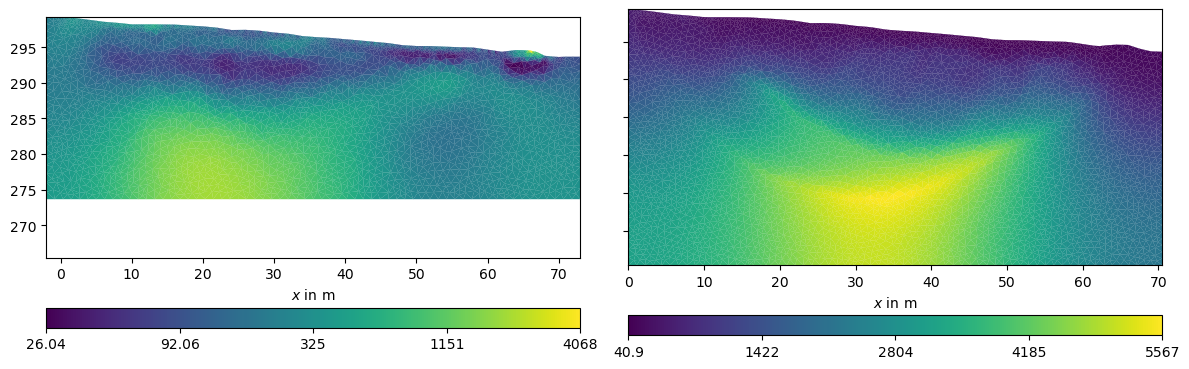

In [35]:
fig, (ax1, ax2) = plt.subplots(1,2, figsize=(12,6), sharey=True)
pg.show(inv_ert, inv_ert["Resistivity"], ax=ax1, logScale=True)
pg.show(inv_srt, inv_srt["Traveltime"], ax=ax2)
for a in ax1, ax2:
    ax.set_ylim(275,300)
fig.tight_layout()

## 3.2) Generate 1D line plots

In [36]:
x_coord = 50
ERT_1D, y_ERT = generate_virtual_borehole(inv_ert, inv_ert["Resistivity"], x_coord)
SRT_1D, y_SRT = generate_virtual_borehole(inv_srt, inv_srt["Traveltime"], x_coord)

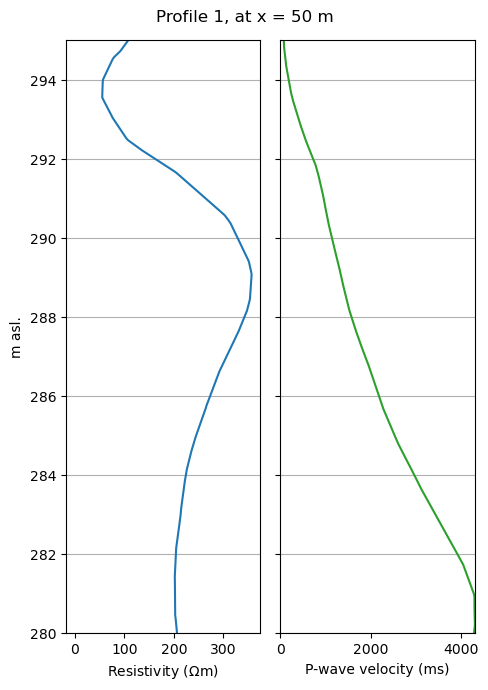

In [37]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(5, 7), sharey=True)

# ERT profile
ax1.plot(ERT_1D, y_ERT, c="tab:blue")
ax1.set_ylabel("m asl.")
ax1.set_xlabel(r"Resistivity ($\Omega$m)")

# SRT profile
ax2.plot(SRT_1D, y_SRT, c="tab:green")
ax2.set_xlabel("P-wave velocity (ms)")
ax2.set_xlim(np.nanmin(SRT_1D), np.nanmax(SRT_1D))

for ax in ax1, ax2:
    ax.set_ylim(280,295)
    ax.grid(axis="y")

fig.suptitle(f"Profile 1, at x = {x_coord} m")
fig.tight_layout()